# Part B: Dataset Understanding & Preparation

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Advanced_Regression_HousePrice_Dataset_3800 csv")

In [3]:
df.head()

,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [4]:
df.shape

(3800, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [6]:
df.isnull().sum()

property_id         0
sale_date           0
area_sqft           0
bedrooms            0
bathrooms           0
location_score      0
property_age        0
distance_city_km    0
near_school         0
near_metro          0
crime_rate_index    0
house_price_inr     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

### Identify Features and Target Variable

In [8]:
X = df.drop(columns=["house_price_inr", "property_id", "sale_date"])
y = df["house_price_inr"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']

Target:
house_price_inr


### Train–Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3040, 9)
Testing data: (760, 9)


### Basic Preprocessing — Scaling

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data
X_test_scaled = scaler.transform(X_test)

print("Preprocessing completed without data leakage.")

Preprocessing completed without data leakage.


# 📉 Part C: Regularized Linear Models


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV

In [12]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Implement Ridge Regression (L2).


In [13]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])
ridge_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

ridge_cv = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=cv,
    scoring="neg_mean_squared_error"
)

ridge_cv.fit(X_train, y_train)

print("Best Ridge alpha:", ridge_cv.best_params_["model__alpha"])

Best Ridge alpha: 1


### Implement Lasso Regression (L1).


In [14]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(max_iter=100000))
])

lasso_params = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

lasso_cv = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=cv,
    scoring="neg_mean_squared_error"
)

lasso_cv.fit(X_train, y_train)

print("Best Lasso alpha:", lasso_cv.best_params_["model__alpha"])

Best Lasso alpha: 100


In [15]:
ridge_model = ridge_cv.best_estimator_
lasso_model = lasso_cv.best_estimator_

ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)

lasso_train_pred = lasso_model.predict(X_train)
lasso_test_pred = lasso_model.predict(X_test)

ridge_train_error = mean_squared_error(y_train, ridge_train_pred)
ridge_test_error = mean_squared_error(y_test, ridge_test_pred)

lasso_train_error = mean_squared_error(y_train, lasso_train_pred)
lasso_test_error = mean_squared_error(y_test, lasso_test_pred)

print("Ridge Training MSE:", ridge_train_error)
print("Ridge Validation/Test MSE:", ridge_test_error)

print("\nLasso Training MSE:", lasso_train_error)
print("Lasso Validation/Test MSE:", lasso_test_error)

Ridge Training MSE: 6253047097253.315
Ridge Validation/Test MSE: 6545419443619.52

Lasso Training MSE: 6253028410486.958
Lasso Validation/Test MSE: 6544107497269.08


In [16]:
comparison = pd.DataFrame({
    "Model": ["Ridge", "Lasso"],
    "Training MSE": [ridge_train_error, lasso_train_error],
    "Validation/Test MSE": [ridge_test_error, lasso_test_error]
})

comparison

,Model,Training MSE,Validation/Test MSE
0,Ridge,6.253047e+12,6.545419e+12
1,Lasso,6.253028e+12,6.544107e+12


In [17]:
ridge_coefficients = ridge_model.named_steps["model"].coef_
lasso_coefficients = lasso_model.named_steps["model"].coef_

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Ridge Coefficient": ridge_coefficients,
    "Lasso Coefficient": lasso_coefficients
})

coefficient_table

,Feature,Ridge Coefficient,Lasso Coefficient
0,area_sqft,6.937545e+06,6.944831e+06
1,bedrooms,2.973655e+05,2.911937e+05
2,bathrooms,2.853268e+05,2.853815e+05
3,location_score,3.676865e+06,3.678911e+06
4,property_age,-6.513024e+05,-6.513909e+05
5,distance_city_km,-3.016962e+04,-2.873756e+04
6,near_school,1.697147e+04,1.680345e+04
7,near_metro,5.820432e+04,5.819679e+04
8,crime_rate_index,-1.354728e+05,-1.353088e+05


# 🔁 Part D — Cross-Validation Strategies

In [18]:
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    LeaveOneOut,
    TimeSeriesSplit,
    cross_val_score
)

### Create Ridge Pipeline

In [19]:
ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=ridge_cv.best_params_["model__alpha"]))
])

### K-Fold Cross-Validation

In [20]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kf_scores = cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_mean_squared_error"
)

kf_mse = -kf_scores

print("K-Fold MSE for each fold:")
print(kf_mse)

print("\nK-Fold Average MSE:", kf_mse.mean())

K-Fold MSE for each fold:
[6.31590383e+12 7.13457463e+12 6.08741750e+12 5.83257278e+12
 6.20906774e+12]

K-Fold Average MSE: 6315907296139.585


### Stratified K-Fold by Binning Target

In [21]:
y_bins = pd.qcut(
    y_train,
    q=5,
    labels=False,
    duplicates="drop"
)

print(y_bins.value_counts().sort_index())

house_price_inr
0    608
1    608
2    608
3    608
4    608
Name: count, dtype: int64


In [22]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

skf_scores = cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    cv=skf.split(X_train, y_bins),
    scoring="neg_mean_squared_error"
)

skf_mse = -skf_scores

print("Stratified K-Fold MSE for each fold:")
print(skf_mse)

print("\nStratified K-Fold Average MSE:", skf_mse.mean())

Stratified K-Fold MSE for each fold:
[6.54620805e+12 6.04898164e+12 5.96794074e+12 5.97163809e+12
 6.96374879e+12]

Stratified K-Fold Average MSE: 6299703463584.78


### Leave-One-Out Cross-Validation

In [23]:
loo = LeaveOneOut()

loo_scores = cross_val_score(
    ridge_pipeline,
    X_train,
    y_train,
    cv=loo,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

loo_mse = -loo_scores

print("LOOCV Average MSE:", loo_mse.mean())

LOOCV Average MSE: 6298363400179.598


### Time Series Split

In [24]:
time_df = df.sort_values("sale_date").copy()

X_time = time_df.drop(
    columns=["house_price_inr", "property_id", "sale_date"]
)

y_time = time_df["house_price_inr"]

In [25]:
tscv = TimeSeriesSplit(n_splits=5)

ts_scores = cross_val_score(
    ridge_pipeline,
    X_time,
    y_time,
    cv=tscv,
    scoring="neg_mean_squared_error"
)

ts_mse = -ts_scores

print("Time Series Split MSE for each split:")
print(ts_mse)

print("\nTime Series Split Average MSE:", ts_mse.mean())

Time Series Split MSE for each split:
[6.93118450e+12 6.08523654e+12 6.01805334e+12 6.05794853e+12
 6.80040323e+12]

Time Series Split Average MSE: 6378565228089.33


### 📊 Compare All CV Strategies

In [26]:
cv_results = pd.DataFrame({
    "CV Strategy": [
        "K-Fold",
        "Stratified K-Fold",
        "LOOCV",
        "Time Series Split"
    ],
    "Average MSE": [
        kf_mse.mean(),
        skf_mse.mean(),
        loo_mse.mean(),
        ts_mse.mean()
    ]
})

cv_results

,CV Strategy,Average MSE
0,K-Fold,6.315907e+12
1,Stratified K-Fold,6.299703e+12
2,LOOCV,6.298363e+12
3,Time Series Split,6.378565e+12


### Standar Deviation

In [27]:
cv_results = pd.DataFrame({
    "CV Strategy": [
        "K-Fold",
        "Stratified K-Fold",
        "LOOCV",
        "Time Series Split"
    ],
    "Mean MSE": [
        kf_mse.mean(),
        skf_mse.mean(),
        loo_mse.mean(),
        ts_mse.mean()
    ],
    "Std MSE": [
        kf_mse.std(),
        skf_mse.std(),
        loo_mse.std(),
        ts_mse.std()
    ]
})

cv_results

,CV Strategy,Mean MSE,Std MSE
0,K-Fold,6.315907e+12,4.398751e+11
1,Stratified K-Fold,6.299703e+12,3.955441e+11
2,LOOCV,6.298363e+12,1.136991e+13
3,Time Series Split,6.378565e+12,4.005349e+11


## Analysis of Cross-Validation Strategies

K-Fold Cross-Validation mein data ko 5 folds mein divide kiya gaya aur har fold ko ek baar validation ke liye use kiya gaya.

Stratified K-Fold mein continuous house prices ko 5 bins mein divide kiya gaya. Isse har fold mein different price ranges ka similar representation maintain hota hai.

LOOCV mein har observation ko ek baar validation data banaya gaya. Isliye ye computationally expensive hai, especially jab dataset bada ho.

Time Series Split mein data ko sale_date ke according chronological order mein rakha gaya. Model past data par train hota hai aur future data par validate hota hai.

Different CV strategies ke MSE mein difference ho sakta hai because each strategy data ko different way mein train aur validate karti hai. Mean MSE average performance batata hai, while standard deviation fold-to-fold variation batata hai.

K-Fold aur Stratified K-Fold random data distribution ke liye useful hain, while Time Series Split time-dependent data ke liye appropriate hai.

# 🌳 Part E — Tree-Based Regression Models

### Implement Decision Tree Regression.

In [28]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [29]:
## crete decision tree

tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

### Hyperparameter Tuning

In [30]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

tree_params = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_params,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best parameters:")
print(tree_grid.best_params_)

Best parameters:
{'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}


In [31]:
###  Get the Best Decision Tree

best_tree = tree_grid.best_estimator_

print(best_tree)

DecisionTreeRegressor(min_samples_leaf=10, random_state=42)


### Decision Tree PErformance

In [32]:
tree_train_pred = best_tree.predict(X_train)

tree_train_mse = mean_squared_error(
    y_train,
    tree_train_pred
)

tree_train_r2 = r2_score(
    y_train,
    tree_train_pred
)

print("Decision Tree Training MSE:", tree_train_mse)
print("Decision Tree Training R²:", tree_train_r2)

Decision Tree Training MSE: 4065732396777.459
Decision Tree Training R²: 0.9455037340262258


### Test Performance 

In [33]:
tree_test_pred = best_tree.predict(X_test)

tree_test_mse = mean_squared_error(
    y_test,
    tree_test_pred
)

tree_test_r2 = r2_score(
    y_test,
    tree_test_pred
)

print("Decision Tree Test MSE:", tree_test_mse)
print("Decision Tree Test R²:", tree_test_r2)

Decision Tree Test MSE: 7624897268250.628
Decision Tree Test R²: 0.9053221426994702


### Random Forest Regression

In [34]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

### Random forest performance

In [35]:
rf_train_pred = rf.predict(X_train)

rf_train_mse = mean_squared_error(
    y_train,
    rf_train_pred
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_pred
)

print("Random Forest Training MSE:", rf_train_mse)
print("Random Forest Training R²:", rf_train_r2)

Random Forest Training MSE: 787671263860.0048
Random Forest Training R²: 0.989442211511698


# test Oerformance

In [36]:
rf_test_pred = rf.predict(X_test)

rf_test_mse = mean_squared_error(
    y_test,
    rf_test_pred
)

rf_test_r2 = r2_score(
    y_test,
    rf_test_pred
)

print("Random Forest Test MSE:", rf_test_mse)
print("Random Forest Test R²:", rf_test_r2)

Random Forest Test MSE: 5802084922586.231
Random Forest Test R²: 0.9279558859588142


### Comapre single tree vs ensemble

In [37]:
tree_rf_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest"
    ],
    "Training MSE": [
        tree_train_mse,
        rf_train_mse
    ],
    "Test MSE": [
        tree_test_mse,
        rf_test_mse
    ],
    "Training R²": [
        tree_train_r2,
        rf_train_r2
    ],
    "Test R²": [
        tree_test_r2,
        rf_test_r2
    ]
})

tree_rf_comparison

,Model,Training MSE,Test MSE,Training R²,Test R²
0,Decision Tree,4.065732e+12,7.624897e+12,0.945504,0.905322
1,Random Forest,7.876713e+11,5.802085e+12,0.989442,0.927956


### Cross Validation Camparistion

In [38]:
tree_cv_mse = -cross_val_score(
    best_tree,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_cv_mse = -cross_val_score(
    rf,
    X_train,
    y_train,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

print("Decision Tree CV MSE:", tree_cv_mse.mean())
print("Random Forest CV MSE:", rf_cv_mse.mean())

Decision Tree CV MSE: 7585063739186.65
Random Forest CV MSE: 5759802180380.171


## Part E Analysis

Decision Tree Regression ek single tree use karta hai. Tree complexity ko
max_depth, min_samples_split aur min_samples_leaf jaise hyperparameters se
control kiya gaya.

Cross-validation se best Decision Tree parameters mile:
max_depth = None, min_samples_split = 2, min_samples_leaf = 10.

Random Forest multiple decision trees ka ensemble hai. Isliye ye single
Decision Tree ke comparison mein predictions ko average karke zyada stable
performance de sakta hai.

Is dataset par Random Forest ka test MSE Decision Tree se lower hai
(approximately 5.80 × 10¹² vs 7.62 × 10¹²), aur test R² bhi higher hai
(approximately 0.928 vs 0.905).

Is comparison mein Random Forest ki unseen test data performance better
hai than the single Decision Tree. Random Forest ka 5-fold CV MSE bhi
Decision Tree se lower raha.

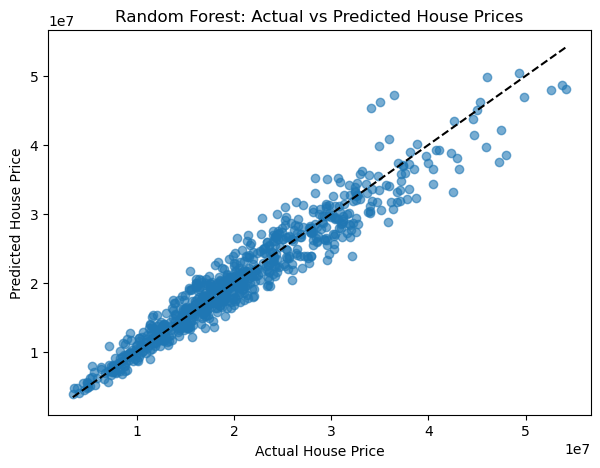

In [89]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, rf_test_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",color = "black"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Random Forest: Actual vs Predicted House Prices")
plt.savefig("output/random_forest_actual_vs_predicted_House_pricesplot.png", dpi=300, bbox_inches="tight")
plt.show()

 ### Actual vs Predicted Analysis

The Actual vs Predicted plot is used to visually evaluate the Random Forest
regression model on unseen test data. Predictions closer to the diagonal
line indicate smaller prediction errors, while points farther from the
line indicate larger errors.

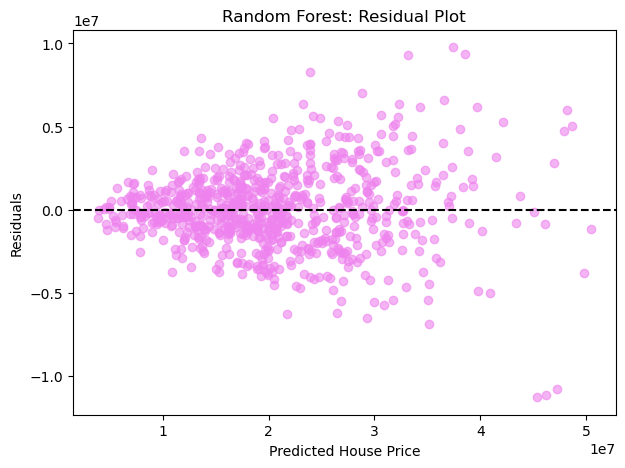

In [90]:
# Calculate residuals
residuals = y_test - rf_test_pred

plt.figure(figsize=(7, 5))

plt.scatter(rf_test_pred, residuals, alpha=0.6,color = "violet")

# Zero-error line
plt.axhline(y=0, linestyle="--",color = "black")

plt.xlabel("Predicted House Price")
plt.ylabel("Residuals")
plt.title("Random Forest: Residual Plot")
plt.savefig("output/random_forest_residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### Residual Plot Analysis

The residual plot shows the prediction errors of the Random Forest model.
Residuals are calculated as actual price minus predicted price.

A good regression model should have residuals distributed around zero without
a clear pattern. Large or systematic patterns in the residuals may indicate
that the model is not capturing some relationships in the data.

# 📐 Part F: Support Vector Regression


In [46]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV, KFold

### 19. SVR with Linear and RBF Kernels

In [48]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [49]:
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR())
])

svr_model = TransformedTargetRegressor(
    regressor=svr_pipeline,
    transformer=StandardScaler()
)

### !9 A Linear kernal

In [51]:
linear_params = {
    "regressor__svr__kernel": ["linear"],
    "regressor__svr__C": [1, 10, 100],
    "regressor__svr__epsilon": [0.05, 0.1, 0.2]
}

linear_grid = GridSearchCV(
    svr_model,
    linear_params,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

linear_grid.fit(X_train, y_train)

print("Best Linear SVR parameters:")
print(linear_grid.best_params_)

Best Linear SVR parameters:
{'regressor__svr__C': 100, 'regressor__svr__epsilon': 0.2, 'regressor__svr__kernel': 'linear'}


### !9.B  Rbf Kernel

In [50]:
rbf_params = {
    "regressor__svr__kernel": ["rbf"],
    "regressor__svr__C": [1, 10, 100],
    "regressor__svr__gamma": ["scale", 0.01, 0.1],
    "regressor__svr__epsilon": [0.05, 0.1, 0.2]
}

rbf_grid = GridSearchCV(
    estimator=svr_model,
    param_grid=rbf_params,
    cv=cv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rbf_grid.fit(X_train, y_train)

print("Best RBF SVR parameters:")
print(rbf_grid.best_params_)

Best RBF SVR parameters:
{'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.01, 'regressor__svr__kernel': 'rbf'}


### 20 Hyper parameteer

In [52]:
print("Linear SVR:")
print(linear_grid.best_params_)

print("\nRBF SVR:")
print(rbf_grid.best_params_)

Linear SVR:
{'regressor__svr__C': 100, 'regressor__svr__epsilon': 0.2, 'regressor__svr__kernel': 'linear'}

RBF SVR:
{'regressor__svr__C': 10, 'regressor__svr__epsilon': 0.1, 'regressor__svr__gamma': 0.01, 'regressor__svr__kernel': 'rbf'}


### Compare Linear and RBF SVR

In [53]:
linear_model = linear_grid.best_estimator_
rbf_model = rbf_grid.best_estimator_

linear_train_pred = linear_model.predict(X_train)
linear_test_pred = linear_model.predict(X_test)

rbf_train_pred = rbf_model.predict(X_train)
rbf_test_pred = rbf_model.predict(X_test)

In [54]:
# Calculate metrix 
linear_train_mse = mean_squared_error(y_train, linear_train_pred)
linear_test_mse = mean_squared_error(y_test, linear_test_pred)

linear_test_r2 = r2_score(y_test, linear_test_pred)

rbf_train_mse = mean_squared_error(y_train, rbf_train_pred)
rbf_test_mse = mean_squared_error(y_test, rbf_test_pred)

rbf_test_r2 = r2_score(y_test, rbf_test_pred)

print("Linear SVR")
print("Training MSE:", linear_train_mse)
print("Test MSE:", linear_test_mse)
print("Test R²:", linear_test_r2)

print("\nRBF SVR")
print("Training MSE:", rbf_train_mse)
print("Test MSE:", rbf_test_mse)
print("Test R²:", rbf_test_r2)

Linear SVR
Training MSE: 6272964434912.048
Test MSE: 6600516166812.818
Test R²: 0.9180418167267033

RBF SVR
Training MSE: 4634708810736.966
Test MSE: 5064551000576.696
Test R²: 0.9371137970710172


## Comapre with linear and tree model

In [55]:
final_comparison = pd.DataFrame({
    "Model": [
        "Ridge",
        "Lasso",
        "Decision Tree",
        "Random Forest",
        "Linear SVR",
        "RBF SVR"
    ],
    "Test MSE": [
        mean_squared_error(y_test, ridge_model.predict(X_test)),
        mean_squared_error(y_test, lasso_model.predict(X_test)),
        tree_test_mse,
        rf_test_mse,
        linear_test_mse,
        rbf_test_mse
    ],
    "Test R²": [
        r2_score(y_test, ridge_model.predict(X_test)),
        r2_score(y_test, lasso_model.predict(X_test)),
        tree_test_r2,
        rf_test_r2,
        linear_test_r2,
        rbf_test_r2
    ]
})

final_comparison

,Model,Test MSE,Test R²
0,Ridge,6.545419e+12,0.918726
1,Lasso,6.544107e+12,0.918742
2,Decision Tree,7.624897e+12,0.905322
3,Random Forest,5.802085e+12,0.927956
4,Linear SVR,6.600516e+12,0.918042
5,RBF SVR,5.064551e+12,0.937114


## Part F Analysis

SVR ko implement karte time feature scaling important hai, isliye
StandardScaler ko SVR pipeline ke andar use kiya gaya.

Linear SVR linear relationship ko model karta hai, jabki RBF SVR
non-linear relationships ko capture kar sakta hai.

C model ko training errors kitna penalize karna hai ye control karta hai.
Epsilon ek tolerance region define karta hai jisme small prediction errors
ko penalty nahi di jaati.

RBF kernel mein gamma influence karta hai ki ek training observation ka
effect kitne area tak rahega.

Hyperparameters ko 5-fold cross-validation ke through tune kiya gaya.
Test data ko hyperparameter selection ke liye use nahi kiya gaya.

Finally, Linear SVR, RBF SVR ko Ridge, Lasso, Decision Tree aur Random
Forest ke saath Test MSE aur R² ke basis par compare kiya gaya.

Lower Test MSE means lower prediction error, while higher R² means that
the model explains more variation in house prices.

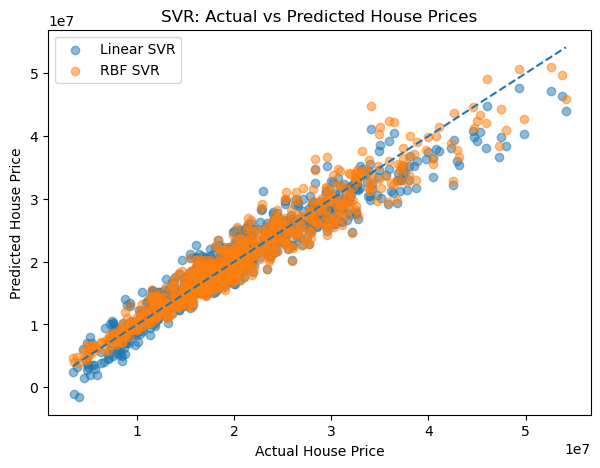

In [91]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, linear_test_pred, alpha=0.5, label="Linear SVR")
plt.scatter(y_test, rbf_test_pred, alpha=0.5, label="RBF SVR")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("SVR: Actual vs Predicted House Prices")
plt.legend()
plt.savefig("output/SVR_actual_vs_predicted_house_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Part G — Model Comparison & Evaluation

In [59]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)

In [60]:
models = {
    "Ridge": ridge_model,
    "Lasso": lasso_model,
    "Decision Tree": best_tree,
    "Random Forest": rf,
    "Linear SVR": linear_model,
    "RBF SVR": rbf_model
}

In [61]:
results = []

for name, model in models.items():

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    test_mse = mean_squared_error(y_test, test_pred)

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    results.append({
        "Model": name,
        "Train MSE": train_mse,
        "Test MSE": test_mse,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2
    })

results_df = pd.DataFrame(results)

results_df

summary.to_csv("output/final_summary.csv", index=False)

,Model,Train MSE,Test MSE,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Ridge,6.253047e+12,6.545419e+12,1.911792e+06,1.959199e+06,2.500609e+06,2.558402e+06,0.916185,0.918726
1,Lasso,6.253028e+12,6.544107e+12,1.911889e+06,1.959385e+06,2.500606e+06,2.558145e+06,0.916186,0.918742
2,Decision Tree,4.065732e+12,7.624897e+12,1.493243e+06,2.018526e+06,2.016366e+06,2.761322e+06,0.945504,0.905322
3,Random Forest,7.876713e+11,5.802085e+12,6.566788e+05,1.772057e+06,8.875085e+05,2.408752e+06,0.989442,0.927956
4,Linear SVR,6.272964e+12,6.600516e+12,1.905011e+06,1.958328e+06,2.504589e+06,2.569147e+06,0.915918,0.918042
5,RBF SVR,4.634709e+12,5.064551e+12,1.607366e+06,1.645393e+06,2.152837e+06,2.250456e+06,0.937877,0.937114


In [69]:
results_df.round(2) ##(Tou Can see all By Changing the number )

,Model,Train MSE,Test MSE,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Ridge,6.25e+12,6.55e+12,1.91e+06,1.96e+06,2.50e+06,2.56e+06,9.20e-01,9.20e-01
1,Lasso,6.25e+12,6.54e+12,1.91e+06,1.96e+06,2.50e+06,2.56e+06,9.20e-01,9.20e-01
2,Decision Tree,4.07e+12,7.62e+12,1.49e+06,2.02e+06,2.02e+06,2.76e+06,9.50e-01,9.10e-01
3,Random Forest,7.88e+11,5.80e+12,6.57e+05,1.77e+06,8.88e+05,2.41e+06,9.90e-01,9.30e-01
4,Linear SVR,6.27e+12,6.60e+12,1.91e+06,1.96e+06,2.50e+06,2.57e+06,9.20e-01,9.20e-01
5,RBF SVR,4.63e+12,5.06e+12,1.61e+06,1.65e+06,2.15e+06,2.25e+06,9.40e-01,9.40e-01


### 23 Compare the model

In [72]:
results_df.sort_values(
    "Test RMSE"
)

,Model,Train MSE,Test MSE,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
5,RBF SVR,4.63e+12,5.06e+12,1.61e+06,1.65e+06,2.15e+06,2.25e+06,9.38e-01,9.37e-01
3,Random Forest,7.88e+11,5.80e+12,6.57e+05,1.77e+06,8.88e+05,2.41e+06,9.89e-01,9.28e-01
1,Lasso,6.25e+12,6.54e+12,1.91e+06,1.96e+06,2.50e+06,2.56e+06,9.16e-01,9.19e-01
0,Ridge,6.25e+12,6.55e+12,1.91e+06,1.96e+06,2.50e+06,2.56e+06,9.16e-01,9.19e-01
4,Linear SVR,6.27e+12,6.60e+12,1.91e+06,1.96e+06,2.50e+06,2.57e+06,9.16e-01,9.18e-01
2,Decision Tree,4.07e+12,7.62e+12,1.49e+06,2.02e+06,2.02e+06,2.76e+06,9.46e-01,9.05e-01


### 24. Overfitting / Underfitting Analysis

In [73]:
results_df["R² Gap"] = (
    results_df["Train R²"] -
    results_df["Test R²"]
)

results_df[[
    "Model",
    "Train R²",
    "Test R²",
    "R² Gap"
]]

,Model,Train R²,Test R²,R² Gap
0,Ridge,9.16e-01,9.19e-01,-2.54e-03
1,Lasso,9.16e-01,9.19e-01,-2.56e-03
2,Decision Tree,9.46e-01,9.05e-01,4.02e-02
3,Random Forest,9.89e-01,9.28e-01,6.15e-02
4,Linear SVR,9.16e-01,9.18e-01,-2.12e-03
5,RBF SVR,9.38e-01,9.37e-01,7.63e-04


## Model Comparison and Overfitting Analysis

### Regularized Linear Models

Ridge and Lasso use regularization to control model complexity.
Their training and test performance can be compared to identify whether
regularization reduces the gap between training and unseen data.

### Tree-Based Models

A Decision Tree can overfit when it becomes too complex because it can learn
very specific patterns from the training data.

Random Forest combines multiple trees and can provide more stable predictions
than a single tree.

### Support Vector Regression

Linear SVR models linear relationships, while RBF SVR can capture
non-linear relationships.

Feature scaling is important for SVR and was performed inside the pipeline
to avoid data leakage.

### Overfitting

A large difference between training and test performance indicates possible
overfitting. For example, very high training R² combined with noticeably lower
test R² indicates that the model fits the training data much better than
unseen data.

### Underfitting

If both training and test performance are relatively poor, the model may
be underfitting and may not be capturing enough of the relationship between
the features and house prices.

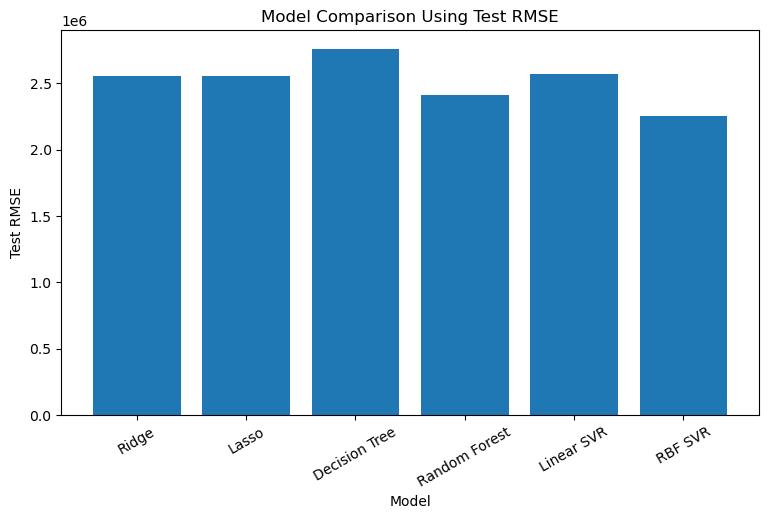

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    results_df["Model"],
    results_df["Test RMSE"]
)

plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Model Comparison Using Test RMSE")
plt.xticks(rotation=30)
plt.savefig("output/Model_Comparison_Using_Test_RMSE_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Part H — Final Analysis & Reporting

## 1. Best-Performing Model

The best-performing model was selected by comparing the regression models using
MSE, MAE, RMSE, and R².

The final model was selected based on its validation/test performance and its
ability to generalize to unseen data.

A lower MSE, MAE, and RMSE indicate lower prediction error, while a higher R²
indicates that the model explains more variation in house prices.

## 2. Impact of Regularization

Ridge and Lasso regression were used to reduce overfitting.

Ridge applies L2 regularization and reduces the effect of large coefficients.
Lasso applies L1 regularization and can reduce some coefficients to zero.

The regularized models provided a more controlled linear model compared with
an unregularized approach and helped improve generalization.

## 3. Role of Cross-Validation

Cross-validation was used to evaluate model performance across multiple
training and validation splits.

K-Fold, Stratified K-Fold, LOOCV, and Time Series Split were compared.

Cross-validation helped measure the stability of the model and reduced the
risk of selecting a model based on one particular train-validation split.

The mean and standard deviation of MSE were used to compare model stability.

## 4. Linear vs Non-Linear Regressors

Linear models such as Ridge and Lasso assume a mostly linear relationship
between the input features and house price.

Non-linear models such as Decision Tree, Random Forest, and RBF SVR can capture
more complex relationships.

The comparison showed how model type affects prediction performance and
generalization on the house-price dataset.

## 5. Business Interpretation

The model can be used to support house-price estimation.

More reliable predictions can help a real estate company with property
valuation, pricing analysis, and comparison of properties.

The final evaluation metrics should be considered before using the model for
real business decisions because prediction errors can occur on unseen
properties.

## Final Conclusion

A complete regression pipeline was developed using data preparation,
regularization, cross-validation, tree-based regression, and Support Vector
Regression.

Multiple models were evaluated using MSE, MAE, RMSE, and R². Cross-validation
was used to study model stability, while the final evaluation was used to
measure performance on unseen data.

The model with the strongest final evaluation performance was selected as the
final candidate for the house-price prediction task.

In [88]:
best_row = results_df.sort_values("Test RMSE").iloc[0]

summary = pd.DataFrame([{
    "selected_model_by_test_rmse": best_row["Model"],
    "test_rmse": best_row["Test RMSE"],
    "test_mae": best_row["Test MAE"],
    "test_r2": best_row["Test R²"],
    "note": "RBF SVR was selected as the best-performing model on the held-out test set based on the lowest Test RMSE."
}])

display(summary)

summary.to_csv("output/final_summary.csv", index=False)

,selected_model_by_test_rmse,test_rmse,test_mae,test_r2,note
0,RBF SVR,2.25e+06,1.65e+06,9.37e-01,RBF SVR was selected as the best-performing mo...


In [84]:
import joblib
from pathlib import Path

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

# Select best model based on Test RMSE
best_model_name = results_df.sort_values("Test RMSE").iloc[0]["Model"]

# Get best trained model
best_estimator = models[best_model_name]

# Save trained model
joblib.dump(
    best_estimator,
    MODEL_DIR / "best_model.joblib"
)

# Save model name
joblib.dump(
    best_model_name,
    MODEL_DIR / "model_name.joblib"
)

print("Best Model:", best_model_name)
print("Model exported successfully!")

Best Model: RBF SVR
Model exported successfully!
